# <img src="assets/logo_infnetv1.png" alt="Infnet logo" height="45"/> Projeto de Disciplina Algoritmos de Clusterização
<img src="https://img.shields.io/badge/python-v._3.11.5-blue?style=flat-square&logo=python&logoColor=white" alt="python_logo" height="20"/>
<img src="https://img.shields.io/badge/jupyter-v._5.7.2-blue?style=flat-square&logo=jupyter&logoColor=white" alt="jupyter_logo" height="20"/>
<img src="https://img.shields.io/badge/anaconda-v._23.7.4-blue?style=flat-square&logo=anaconda&logoColor=white" alt="anaconda_logo" height="20"/>

#### Aluno: 

- Lauro Barbosa <a href="https://github.com/LMRocha/pd_algoritmos_clusterizacao"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/></a>
---

### Sobre o Dataset escolhido:

<p style="color: green;">Se trata de um modelo de aprendizagem não supervisionado de clusterização relativos a dados de um shopping que contém os dados segmentados dos clientes que o frequentam. Os dados foram extraídos do site do <a href="https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python">`Kaggle`</a>.
</p>

### Motivação:

<p style="color: green;">Este dataset foi escolhido por ter mais dados que o <a href="https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data">`Dataset anteriormente analisado`</a>, e por esboçar um caso de uso real bem próximo a realidade cotidiana. Também como motivação secundária, foi o desconhecimento da quantidade de "Clusters" ideais, ja que o anterior tinha uma quantidade ja determinado</p>

#### Convenções de reprodutibilidade:

- Todas as bibliotecas se encontram no arquivo `📄requirements.txt`
- Para mais informações, consulte nosso `README.md`

## Ambiente de execução
<p style="color: green;">Evidência do ambiente utilizado.</p>

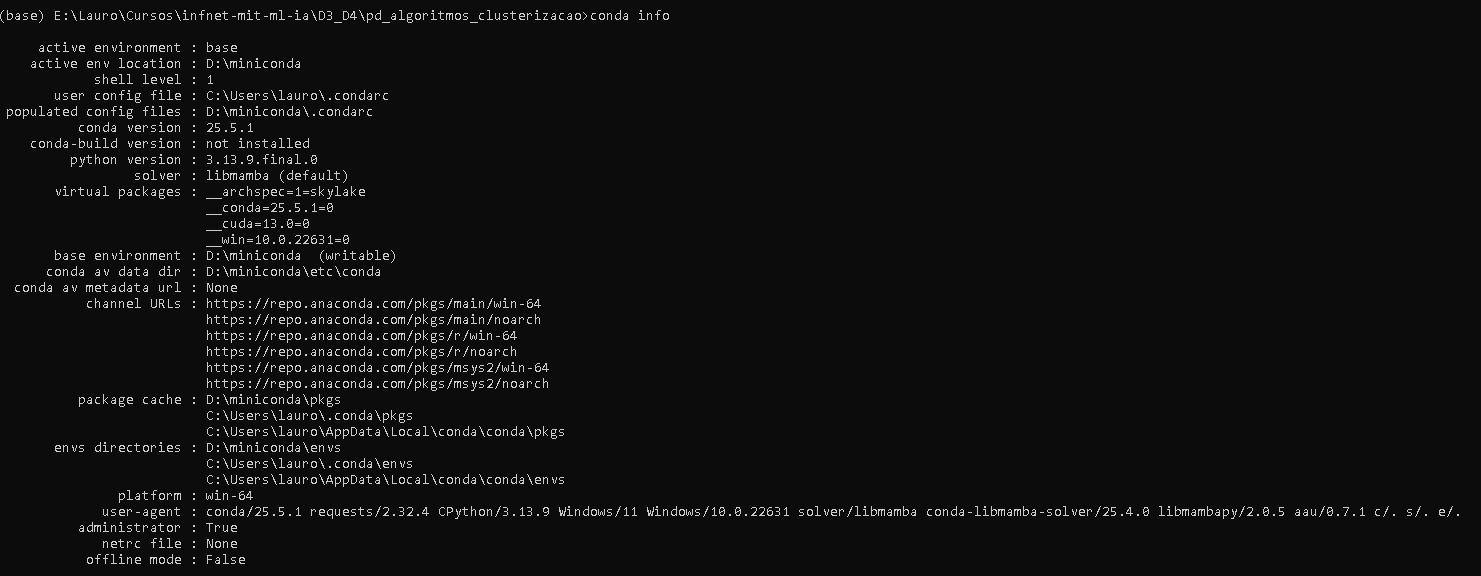

## Importação as bibliotecas

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn import metrics

SEED=42

## Geração dos diretórios e download do dataset

In [21]:
# Inicializar a API do Kaggle
api = KaggleApi()
api.authenticate()

# Criar o diretório se não existir
data_path = 'data'
os.makedirs(data_path, exist_ok=True)

# Baixar os dados do Kaggle.
api.dataset_download_files('vjchoudhary7/customer-segmentation-tutorial-in-python', path=data_path, unzip=True)

path_raw = 'data/'
file_raw_1 = 'Mall_Customers.csv'
pathfile_raw_1 = os.path.join(path_raw, file_raw_1)

Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python


## Definição de funções

In [22]:
def histogram_per_variable_plot(X):
    for col in X.columns:
        plt.figure()
        plt.hist(X[col].dropna())
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("freq")
        plt.show()

def boxplot_per_variable_plot(X):
    for col in X.columns:
        plt.figure()
        plt.boxplot(X[col].dropna())
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("freq")
        plt.show()

def pair_plot(data,figsize_x,figsize_y):
    sns.pairplot(data=data,diag_kind='kde')
    plt.figure(figsize=(figsize_x, figsize_y))
    plt.show()

def scatter_plot(data,x,y,clusters):
    sns.scatterplot(data=data,x=x,y=y,hue=clusters)
    plt.figure(figsize=(10,6))
    plt.show()


def line_plot(data,x,y,title,x_label,y_label):
    plt.figure(12,5)
    plt.plot(data=data,x=x,y=y)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

def bar_plot(data,x,y,title,x_label,y_label):
    plt.figure(12,5)
    plt.bar(data=data,x=x,y=y)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    
def plot_data_clusters(data,centroids):
    for c in sorted(np.unique(data['cluster'])):
        subset = data[data["cluster"] == c]
        plt.scatter(subset["PCA1"], subset["PCA2"], s=80, alpha=0.8, label=f"Cluster {c}")

    plt.scatter(centroids[:,0], centroids[:,1], marker="X", s=100)
    plt.title("Clusters de Países")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_metricas(metricas,metrica_nome):
    plt.figure(figsize=(10, 6))
    plt.plot(metricas)
    plt.xlabel("k")
    plt.ylabel(metrica_nome)
    plt.legend()
    plt.show()

def generate_wss_score(model,data):
    return model.fit(data).inertia_

def generate_silhouette_score(model,data):
    labels = model.fit_predict(data)
    return metrics.silhouette_score(X=data,labels=labels)

def generate_davies_score(model,data):
    labels = model.fit_predict(data)
    return metrics.davies_bouldin_score(X=data,labels=labels)

def generate_calinsky_score(model,data):
    labels = model.fit_predict(data)
    return metrics.calinski_harabasz_score(X=data,labels=labels)

## Análise Exploratória

### Detalhamento do Dataset

In [23]:
df = pd.read_csv(pathfile_raw_1)
df['Gender'] = df['Gender'].replace('Male', 1).replace('Female',0)
df.head()

C:\Users\lauro\AppData\Local\Temp\ipykernel_21856\2831002275.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace('Male', 1).replace('Female',0)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


<span style="color: green;">Gráficos demonstrando as faixas dinâmicas através do BoxPlot</span>

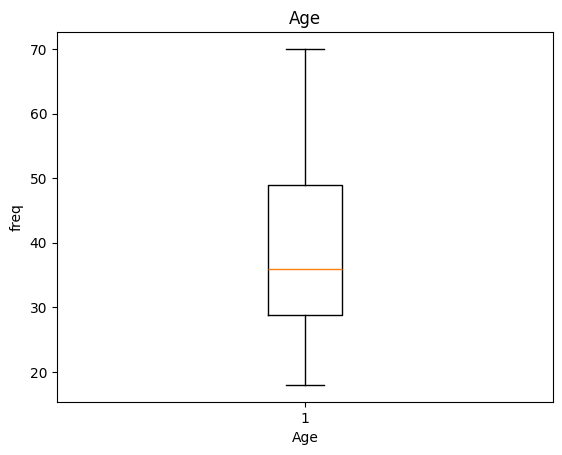

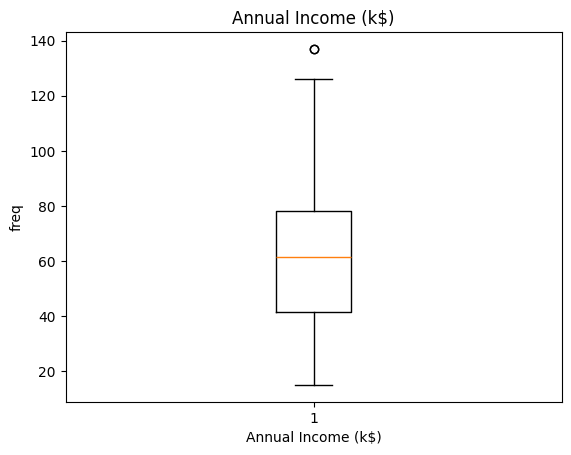

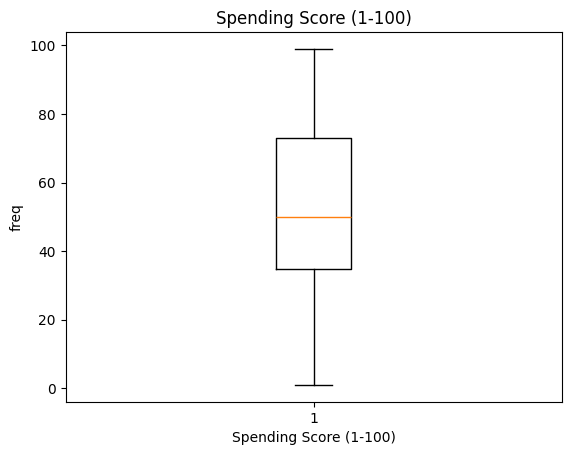

In [24]:
boxplot_per_variable_plot(df.drop(['CustomerID','Gender'],axis=1))

## Pré Processamento

<b> Verificação de dados nulos no dataset

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


<b> Verificacao de dados duplicados no dataset

In [26]:
df[df.duplicated()==True]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


<b> Remoção de colunas

In [27]:
X = df.drop(['CustomerID','Gender'],axis=1)
X

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


<b> Padronização  dos dados

In [28]:
columns = X.columns

In [29]:
scaler = StandardScaler()
Xs = pd.DataFrame(columns=columns,data=scaler.fit_transform(X))
Xs

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


## Treinamento

### Treinamento KMeans

<b>Extração das métricas para encontrar a quantidade ideal de clusters</b>

<p style="color: green;">Conforme a análise da métrica de <b>Silhouette</b>, a quantidade ideal de clusters encontrada foram 4.</p>

In [30]:
metrica_wss = []
metrica_silhouette = []
metrica_davies= []
metrica_calinsky = []
for i in range(2,15):
        model = KMeans(n_clusters=i,random_state=SEED)
        metrica_wss.append(generate_wss_score(model=model,data=Xs))
        metrica_silhouette.append(generate_silhouette_score(model=model,data=Xs))
        metrica_davies.append(generate_davies_score(model=model,data=Xs))
        metrica_calinsky.append(generate_calinsky_score(model=model,data=Xs))

metricas = {'wss':metrica_wss,
            'sil':metrica_silhouette,
            'dvs':metrica_davies,
            'cal':metrica_calinsky}

C:\Users\lauro\AppData\Local\Temp\ipykernel_21856\3712386011.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


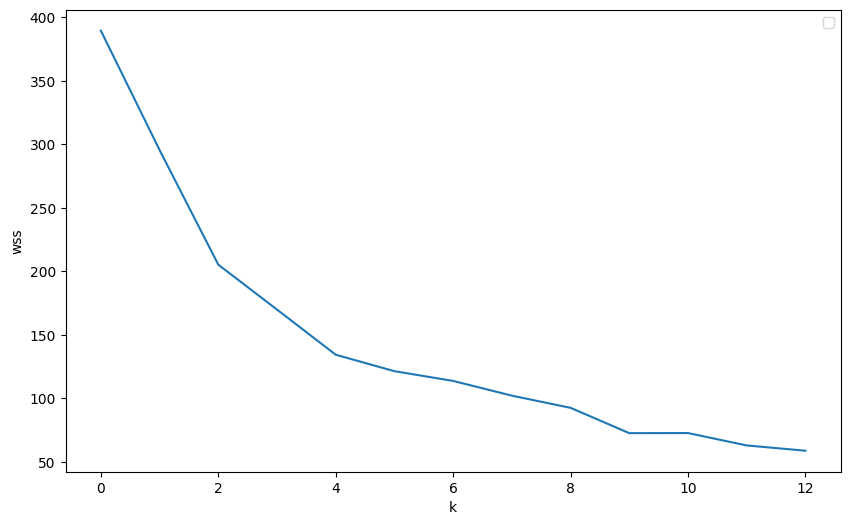

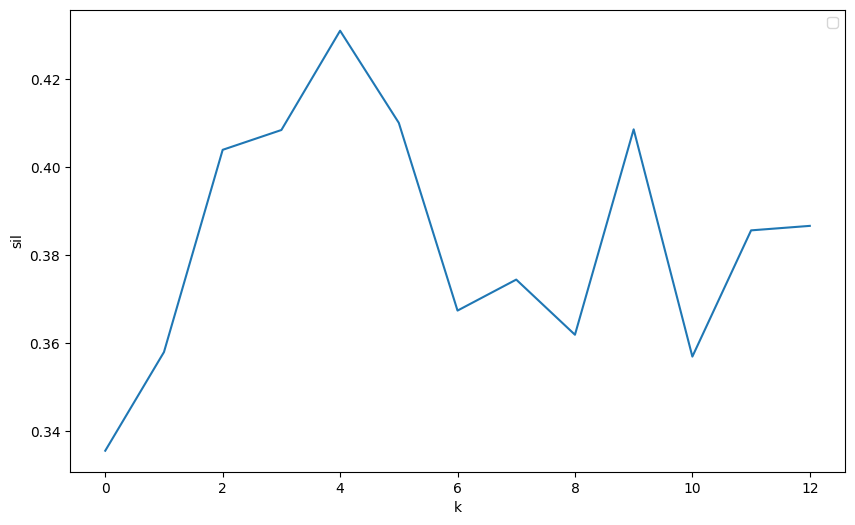

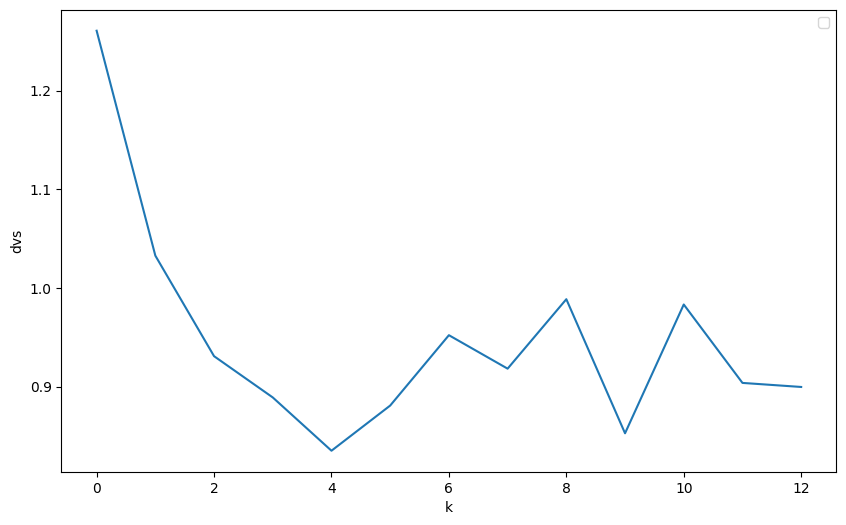

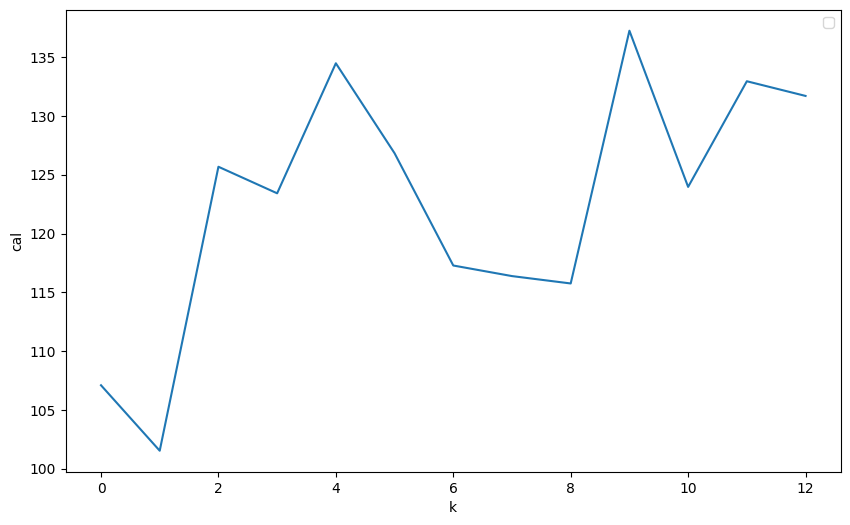

In [31]:
plot_metricas(metricas['wss'],'wss')
plot_metricas(metricas['sil'],'sil')
plot_metricas(metricas['dvs'],'dvs')
plot_metricas(metricas['cal'],'cal')


<b> realizando o treinamento do modelo kmeans e gerando as labels com a quantidade de clusters ideais

In [32]:
model_kmeans = KMeans(n_clusters=4,random_state=SEED)
km_labels = model_kmeans.fit_predict(Xs)
km_centroids = model_kmeans.cluster_centers_

In [33]:
print(f'labels: \n{km_labels}')
print(f'\ncentroids: \n{km_centroids}')

labels: 
[2 2 2 2 2 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0
 0 2 0 0 2 0 0 2 0 0 2 0 0 2 2 0 0 2 0 0 2 2 0 2 0 2 2 0 0 2 0 2 0 0 0 0 0
 2 3 2 2 2 0 0 0 0 2 3 1 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]

centroids: 
[[ 1.08616125 -0.49056525 -0.39717443]
 [-0.42880597  0.97484722  1.21608539]
 [-0.96249203 -0.78476346  0.39202966]
 [ 0.03720536  0.99011499 -1.18875705]]


In [34]:
metricas_kmeans = {'sil':metrics.silhouette_score(Xs,labels=km_labels),
            'davies':metrics.davies_bouldin_score(Xs,labels=km_labels),
            'wss':model_kmeans.inertia_,
            'cal':metrics.calinski_harabasz_score(Xs,labels=km_labels)}

print(f'Silhouette Score: {metricas_kmeans['sil']}')
print(f'Davies B: {metricas_kmeans['davies']}')
print(f'WSS: {metricas_kmeans['wss']}')
print(f'Calinsky: {metricas_kmeans['cal']}')

Silhouette Score: 0.4039582785148566
Davies B: 0.9307956868103672
WSS: 205.22514747675916
Calinsky: 125.67639662405028


### Treinamento DBScan

In [35]:
model_dbscan = DBSCAN(n_jobs=-1)
dbscan_labels = model_dbscan.fit_predict(Xs)
dbscan_labels

array([-1,  0, -1,  0, -1,  0, -1, -1, -1,  0, -1, -1, -1,  0, -1,  0,  1,
        0, -1, -1,  1,  0, -1,  0, -1,  0,  1, -1,  1,  0, -1,  0, -1,  0,
       -1,  0, -1,  0,  1,  0, -1,  0,  2,  3,  2, -1,  2,  3,  3,  3,  2,
        3,  3,  2,  2,  2,  2,  2,  3,  2,  2,  3,  2,  2,  2,  3,  2,  2,
        3,  3,  2,  2,  2,  2,  2,  3,  2,  2,  3,  2,  2,  2,  2,  2,  3,
        2,  2,  3, -1,  2,  2,  3,  2,  2,  2,  3,  2,  3,  2,  3,  3,  2,
        2,  3,  2,  3,  2,  2,  2,  2,  2,  3,  2,  3,  3,  3,  2,  2,  2,
        2,  3,  2, -1,  4, -1,  4, -1,  4, -1,  4,  5,  4,  3,  4, -1,  4,
        5,  4, -1,  4, -1,  4, -1,  4, -1,  4, -1,  4, -1,  4,  5,  4,  5,
        4,  5,  4, -1,  4, -1,  4, -1,  4, -1,  4, -1,  4,  5,  4, -1, -1,
        5,  4, -1,  4, -1,  4, -1,  4, -1,  4, -1,  4, -1,  4, -1,  4, -1,
       -1, -1,  4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

<b>Geração das métricas do DBScan </b>

In [36]:
dbscan_silhouette = None
dbscan_davies = None
dbscan_calinsky = None

if len(np.unique(dbscan_labels[dbscan_labels!=-1])) > 1:
    dbscan_silhouette = metrics.silhouette_score(Xs,dbscan_labels)
    dbscan_davies = metrics.davies_bouldin_score(Xs,dbscan_labels)
    dbscan_calinsky = metrics.calinski_harabasz_score(Xs,dbscan_labels)

metricas_dbscan = {'sil':dbscan_silhouette,
                   'davies':dbscan_davies,
                   'cal':dbscan_calinsky}

print(f'DBScan Silhouette: {metricas_dbscan['sil']}')
print(f'DBScan Davies Bouldin: {metricas_dbscan['davies']}')
print(f'DBScan Calinsky: {metricas_dbscan['cal']}')

DBScan Silhouette: 0.18451372756506046
DBScan Davies Bouldin: 1.7569458461701164
DBScan Calinsky: 34.07053246361936


## Comparativos

<p style="color: green;">Dado o comparativo entre as métricas coletadas <b>Silhouette</b>, <b>Davies Boulding</b> e <b>Calinsky-Harabasz</b>, foi definido como modelo eleito o modelo <b>K-Means</b>, devido aos seguintes fatores:
<br>&#8226; Métrica silhouete apresentou valor positivo e maior que a do modelo DBScan, demonstrando maior separação dos clusters. 
<br>&#8226; Métrica davies bouldin apresentou valor maior que a do modelo DBScan, demonstrando maiors similaridade.
<br>&#8226; Métrica Calinsky Hararabazs apresentou valor maior que a do modelo DBScan, demonstrando maior densidade dos clusters.
</p>

In [37]:
df_metricas_kmeans = pd.DataFrame(data=metricas_kmeans,index=['KMeans'])
df_metricas_comparativa = pd.concat([df_metricas_kmeans.drop(['wss'],axis=1),pd.DataFrame(data=metricas_dbscan,index=['DBScan'])])
df_metricas_comparativa

,sil,davies,cal
KMeans,0.403958,0.930796,125.676397
DBScan,0.184514,1.756946,34.070532


<p style="color: green;">Devido a complexidade e a existência de ruidos e diferentes densidades entre os clusters, não torna o indice de silhouette como uma métrica eleita a ser analisada no modelo</p>

<Axes: >

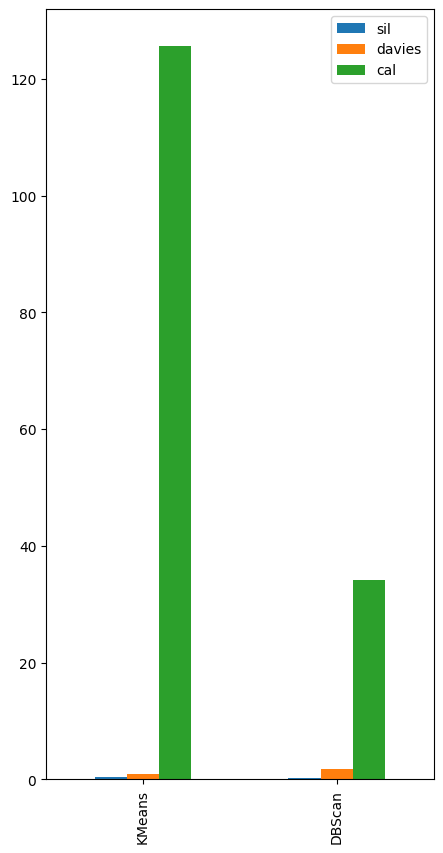

In [38]:
df_metricas_comparativa.plot(kind='bar',figsize=(5,10))

## Medidas de similaridade

**<p style="color: green;">1. Passos para agrupar 10 séries temporais em 3 grupos usando o valor máximo de correlação cruzada</p>**
- <p style="color: green;">Pré-processar as séries (normalização, padronização, tratamento de faltantes).</p>
- <p style="color: green;">Calcular a correlação cruzada para cada par de séries.</p>
- <p style="color: green;">Extrair, o valor máximo da correlação cruzada (considerando todos os lags).</p>
- <p style="color: green;">Construir uma matriz de similaridade 10×10 os valores máximos.</p>
- <p style="color: green;">Criar uma matriz de distâncias usando essas medidas.</p>
- <p style="color: green;">Aplicar um algoritmo de clusterização.</p>

**<p style="color: green;">2. Algoritmo de clusterização recomendado + justificativa</p>**
- <p style="color: green;">Hierarchical Agglomerative Clustering, pois alem de lidar métricas não euclidianas, possui a geração do dendograma que facilita sua vizualização.</p>

**<p style="color: green;">3. Caso de uso para essa solução</p>**
- <p style="color: green;">Quaisquer metrificações de sensores que envolva uma metragem de tempo</p>

**<p style="color: green;">4. Outra estratégia de similaridade:</p>**
- <p style="color: green;">DTW (Dynamic Time Warping): Técnica de metrificação de séries temporais que estejam desalinhadas</p>